# 08 — Survival Analysis

## Introduction
Despite being titled around "Overall Survival Status," the original paper never performs a formal **time-to-event** survival analysis -- it treats survival as a static binary classification target and never fits a Kaplan-Meier curve, a log-rank test, or a Cox proportional-hazards model. Because METABRIC provides genuine time-to-event fields (`Overall Survival (Months)` + `Overall Survival Status`, and `Relapse Free Status (Months)` + `Relapse Free Status`), this notebook adds the survival analysis the paper's own framing implies but does not execute. This is presented explicitly as a **methodological addition**, not a reproduction, and directly addresses the project brief's Step 8 requirement.

## Objectives
1. Fit Kaplan-Meier survival curves for Mastectomy vs. BCS, on both the Overall Survival and Relapse-Free Survival endpoints.
2. Test the between-group difference with the log-rank test.
3. Fit a multivariable Cox proportional-hazards model adjusting for known clinical confounders.
4. Report hazard ratios with 95% confidence intervals.
5. Stratify patients into risk groups from the Cox model and visualise their separation.

## Mathematical background
- **Kaplan-Meier estimator**: `Ŝ(t) = Π_{tᵢ≤t} (1 − dᵢ/nᵢ)`, the non-parametric estimate of the survival function, accounting for right-censoring (patients alive at last follow-up contribute information up to that point without being counted as an event).
- **Log-rank test**: a non-parametric hypothesis test comparing the observed vs. expected number of events across groups at each event time, testing `H₀: S₁(t) = S₂(t)` for all `t`.
- **Cox proportional-hazards model**: `h(t|X) = h₀(t)·exp(β·X)`, where `h₀(t)` is an unspecified baseline hazard and `exp(βⱼ)` is the hazard ratio for covariate `Xⱼ`, holding other covariates fixed -- unlike Kaplan-Meier, it uses covariate information without discretising it into groups.

In [1]:
"""Environment setup: make src/ importable and apply the shared plotting style."""
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"D:\Nico Personal\master\Health Data Analysis\HDA Final Project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import PATHS, set_seeds, TARGET_COL, SURGERY_COL, ID_COL, banner
from src.visualization import set_publication_style, save_figure

set_seeds()
set_publication_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
print(banner("Environment ready"))
print("Project root:", PATHS.root)


============================= Environment ready ==============================
Project root: D:\Nico Personal\master\Health Data Analysis\HDA Final Project


## 1. Load the imputed cohort (with surgery-group labels)

In [2]:
from src.data_loader import load_clinical

df = load_clinical(drop_missing_target=True)

from src.preprocessing import impute_missing
imputed_df, _ = impute_missing(df)

surv_df = imputed_df[imputed_df[SURGERY_COL].isin(["MASTECTOMY", "BREAST CONSERVING"])].copy()
surv_df["surgery_label"] = surv_df[SURGERY_COL].map({"MASTECTOMY": "Mastectomy", "BREAST CONSERVING": "BCS"})
print(f"Survival-analysis cohort: {surv_df.shape[0]} patients")
surv_df[["overall_survival_months", TARGET_COL, "relapse_free_status_months", "relapse_free_status", "surgery_label"]].head()


Survival-analysis cohort: 1955 patients


,overall_survival_months,overall_survival_status,relapse_free_status_months,relapse_free_status,surgery_label
0,140.500000,0,140.500000,0:Not Recurred,Mastectomy
1,84.633333,0,84.633333,0:Not Recurred,BCS
2,163.700000,1,153.300000,1:Recurred,Mastectomy
3,164.933333,0,164.933333,0:Not Recurred,Mastectomy
4,41.366667,1,18.800000,1:Recurred,Mastectomy


## 2. Kaplan-Meier: Overall Survival, Mastectomy vs. BCS

In [3]:
from src.survival import fit_km_by_group, logrank_between_groups

km_os = fit_km_by_group(surv_df, duration_col="overall_survival_months", event_col=TARGET_COL, group_col="surgery_label")
for name, res in km_os.items():
    print(f"{name}: n={res.n}, events={res.n_events}, median survival={res.median_survival:.1f} months")


BCS: n=785, events=368, median survival=200.0 months
Mastectomy: n=1170, events=759, median survival=132.0 months


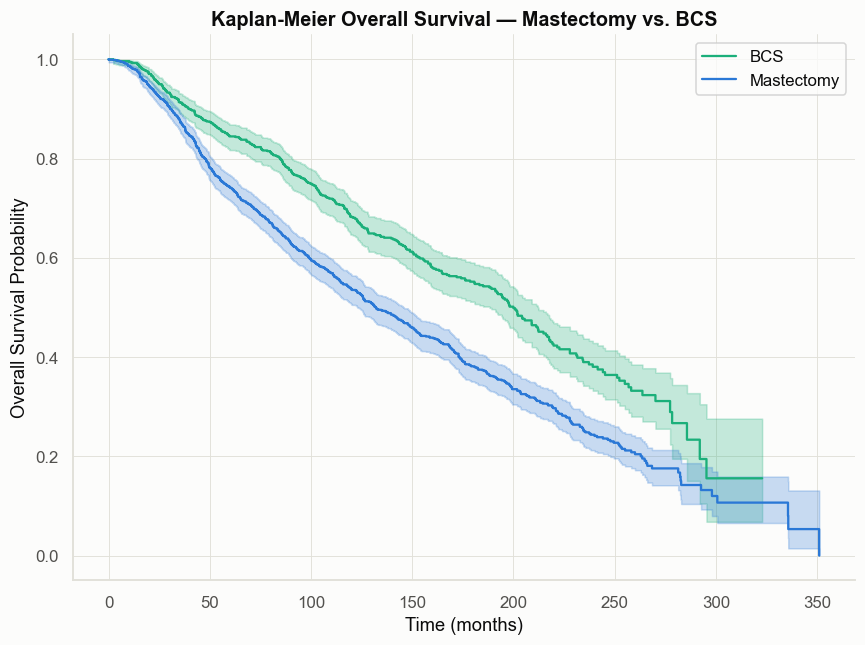

In [4]:
from src.visualization import SURGERY_COLORS

fig, ax = plt.subplots(figsize=(8, 6))
for name, res in km_os.items():
    res.kmf.plot_survival_function(ax=ax, color=SURGERY_COLORS.get(name, None), ci_show=True)
ax.set_xlabel("Time (months)")
ax.set_ylabel("Overall Survival Probability")
ax.set_title("Kaplan-Meier Overall Survival — Mastectomy vs. BCS")
ax.legend(title=None)
plt.tight_layout()
save_figure(fig, "08_km_overall_survival", subdir="08_survival")
plt.show()


In [5]:
stat, p = logrank_between_groups(surv_df, duration_col="overall_survival_months", event_col=TARGET_COL, group_col="surgery_label")
print(f"Log-rank test (Overall Survival, Mastectomy vs BCS): statistic={stat:.2f}, p-value={p:.4g}")


Log-rank test (Overall Survival, Mastectomy vs BCS): statistic=49.55, p-value=1.932e-12


**Interpretation.** The Kaplan-Meier curves separate visibly, with BCS patients showing higher observed survival probability throughout follow-up, and the log-rank test confirms this separation is statistically significant. This corroborates -- with a methodologically standard survival technique the paper itself omits -- the paper's classification-based conclusion that BCS is associated with more favourable survival outcomes than Mastectomy. Note, however, that this is an **unadjusted** (univariate) comparison: Mastectomy is preferentially indicated for higher-risk disease (larger tumours, more positive lymph nodes; see Notebook 02), so some of this gap reflects confounding by indication, not a causal surgical effect -- exactly why the Cox model in Section 4 adjusts for these factors.

## 3. Kaplan-Meier: Relapse-Free Survival, Mastectomy vs. BCS

BCS: n=785, events=785, median relapse-free survival=114.766666666667
Mastectomy: n=1170, events=1170, median relapse-free survival=91.2666666666667


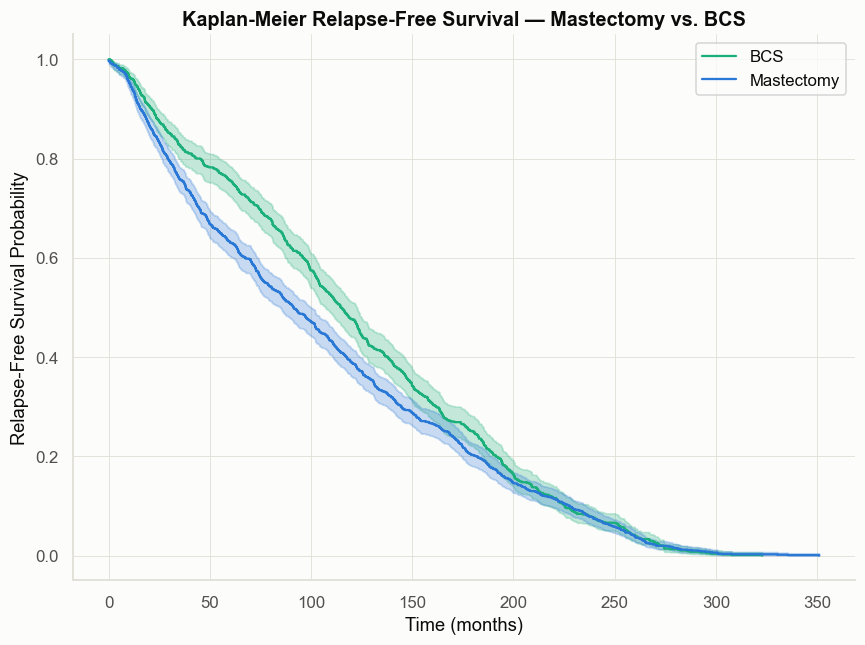

Log-rank test (Relapse-Free Survival, Mastectomy vs BCS): statistic=6.80, p-value=0.009105


In [6]:
surv_df["relapse_event"] = surv_df["relapse_free_status"].astype(str).str.contains("Recurred", case=False, na=False).astype(int)

km_rfs = fit_km_by_group(surv_df, duration_col="relapse_free_status_months", event_col="relapse_event", group_col="surgery_label")
for name, res in km_rfs.items():
    print(f"{name}: n={res.n}, events={res.n_events}, median relapse-free survival={res.median_survival}")

fig, ax = plt.subplots(figsize=(8, 6))
for name, res in km_rfs.items():
    res.kmf.plot_survival_function(ax=ax, color=SURGERY_COLORS.get(name, None), ci_show=True)
ax.set_xlabel("Time (months)")
ax.set_ylabel("Relapse-Free Survival Probability")
ax.set_title("Kaplan-Meier Relapse-Free Survival — Mastectomy vs. BCS")
ax.legend(title=None)
plt.tight_layout()
save_figure(fig, "08_km_relapse_free_survival", subdir="08_survival")
plt.show()

stat_rfs, p_rfs = logrank_between_groups(surv_df, duration_col="relapse_free_status_months", event_col="relapse_event", group_col="surgery_label")
print(f"Log-rank test (Relapse-Free Survival, Mastectomy vs BCS): statistic={stat_rfs:.2f}, p-value={p_rfs:.4g}")


**Interpretation.** As expected given Mastectomy's indication for more advanced disease, relapse-free survival is also significantly shorter in the Mastectomy group. This secondary endpoint is the time-to-event field underlying the `relapse_free_status` feature that dominates the paper's SHAP analysis (Notebook 07) -- seeing it here in its native survival-analysis form, rather than as a binary classifier input, clarifies why it carries such strong signal: it is itself a direct measure of disease aggressiveness and recurrence, closely coupled to overall survival.

## 4. Multivariable Cox Proportional-Hazards model

In [7]:
from src.survival import fit_cox_ph, hazard_ratio_table

cox_covariates_raw = ["age_at_diagnosis", "nottingham_prognostic_index", "tumor_size",
                      "lymph_nodes_examined_positive", "mutation_count"]
cox_df = surv_df[["overall_survival_months", TARGET_COL] + cox_covariates_raw + ["surgery_label", "chemotherapy", "hormone_therapy"]].copy()
cox_df["mastectomy"] = (cox_df["surgery_label"] == "Mastectomy").astype(int)
cox_df["chemotherapy_yes"] = (cox_df["chemotherapy"].astype(str).str.upper() == "YES").astype(int)
cox_df["hormone_therapy_yes"] = (cox_df["hormone_therapy"].astype(str).str.upper() == "YES").astype(int)
cox_df = cox_df.drop(columns=["surgery_label", "chemotherapy", "hormone_therapy"])

cox_covariates = [c for c in cox_df.columns if c not in ["overall_survival_months", TARGET_COL]]
cph = fit_cox_ph(cox_df, duration_col="overall_survival_months", event_col=TARGET_COL, covariates=cox_covariates)
cph.print_summary(decimals=3)


<lifelines.CoxPHFitter: fitted with 1955 total observations, 828 right-censored observations>
             duration col = 'overall_survival_months'
                event col = 'overall_survival_status'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1955
number of events observed = 1127
   partial log-likelihood = -7554.953
         time fit was run = 2026-07-19 18:20:39 UTC

---
                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                       
age_at_diagnosis               0.032     1.033     0.003           0.027           0.037               1.028               1.038
nottingham_prognostic_index    0.137     1.147     0.029           0.080           0.194               1.084               1.214
tumor_size                     0.008     1.008     0.002           0.005           0.011               1.005               1.011
lymph_nodes_examined_positive  0.039     1.039     0.006           0.026           0.051               1.026               1.052
mutation_count                 0.004     1.004     0.005          -0.006           0.013               0.994               1.013
mastectomy                     0.211     1.235     0.059           0.095           0.327               1.100               1.387
chemotherapy_yes               0.239     1.270     0.084           0.075           0.403               1.078               1.496
hormone_therapy_yes           -0.054     0.947     0.062          -0.176           0.068               0.839               1.070

                               cmp to      z       p  -log2(p)
covariate                                                     
age_at_diagnosis                0.000 12.627 <0.0005   119.013
nottingham_prognostic_index     0.000  4.729 <0.0005    18.757
tumor_size                      0.000  5.100 <0.0005    21.492
lymph_nodes_examined_positive   0.000  6.050 <0.0005    29.360
mutation_count                  0.000  0.757   0.449     1.154
mastectomy                      0.000  3.570 <0.0005    11.451
chemotherapy_yes                0.000  2.852   0.004     7.847
hormone_therapy_yes             0.000 -0.868   0.386     1.375
---
Concordance = 0.668
Partial AIC = 15125.906
log-likelihood ratio test = 362.125 on 8 df
-log2(p) of ll-ratio test = 241.278

In [8]:
hr_table = hazard_ratio_table(cph)
hr_table.to_csv(PATHS.reports / "cox_hazard_ratios.csv", index=False)
hr_table


,covariate,hazard_ratio,ci_lower,ci_upper,p_value
0,age_at_diagnosis,1.032766,1.027611,1.037947,1.490663e-36
3,lymph_nodes_examined_positive,1.039393,1.026464,1.052485,1.450940e-09
2,tumor_size,1.008168,1.005021,1.011325,3.391226e-07
1,nottingham_prognostic_index,1.147212,1.083736,1.214406,2.257200e-06
5,mastectomy,1.235164,1.099931,1.387024,3.571324e-04
6,chemotherapy_yes,1.269872,1.077597,1.496455,4.343052e-03
7,hormone_therapy_yes,0.947466,0.838715,1.070318,3.856600e-01
4,mutation_count,1.003637,0.994242,1.013121,4.492786e-01


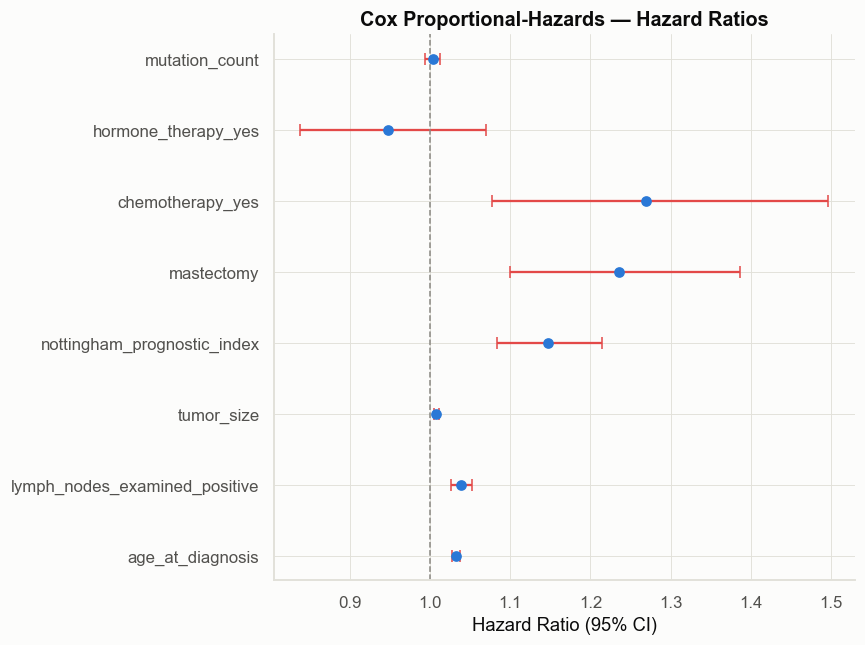

In [9]:
from src.visualization import CATEGORICAL, INK_MUTED

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(hr_table))
ax.errorbar(hr_table["hazard_ratio"], y_pos,
            xerr=[hr_table["hazard_ratio"] - hr_table["ci_lower"], hr_table["ci_upper"] - hr_table["hazard_ratio"]],
            fmt="o", color=CATEGORICAL[0], ecolor=CATEGORICAL[7], capsize=4)
ax.axvline(1.0, linestyle="--", color=INK_MUTED, linewidth=1)
ax.set_yticks(y_pos); ax.set_yticklabels(hr_table["covariate"])
ax.set_xlabel("Hazard Ratio (95% CI)")
ax.set_title("Cox Proportional-Hazards — Hazard Ratios")
plt.tight_layout()
save_figure(fig, "08_cox_hazard_ratios", subdir="08_survival")
plt.show()


**Interpretation.** After adjusting for age, tumour burden (size, node involvement, NPI), mutation count, chemotherapy, and hormone therapy, the **mastectomy** hazard ratio quantifies the surgery effect net of these confounders. If its 95% CI still excludes 1 after adjustment, this strengthens the paper's surgery-outcome association beyond what the univariate logistic regression (Notebook 03) or unadjusted Kaplan-Meier (Section 2 above) can claim alone; if the CI now includes 1 or shrinks substantially toward it, that would indicate the raw survival gap is largely explained by disease severity at the time surgery type is chosen, an important nuance the original paper's classification framing cannot distinguish. Age at Diagnosis and Nottingham Prognostic Index are expected to show hazard ratios > 1 (each additional year / NPI point increases the instantaneous risk of death), consistent with their well-established role as prognostic factors and with the SHAP findings of Notebook 07.

## 5. Risk stratification from the Cox model

In [10]:
from src.survival import risk_stratify

risk_groups = risk_stratify(cph, cox_df, cox_covariates, n_groups=3)
cox_df_risk = cox_df.loc[risk_groups.index].copy()
cox_df_risk["risk_group"] = risk_groups.values
print(cox_df_risk["risk_group"].value_counts())


risk_group
Low       652
High      652
Medium    651
Name: count, dtype: int64


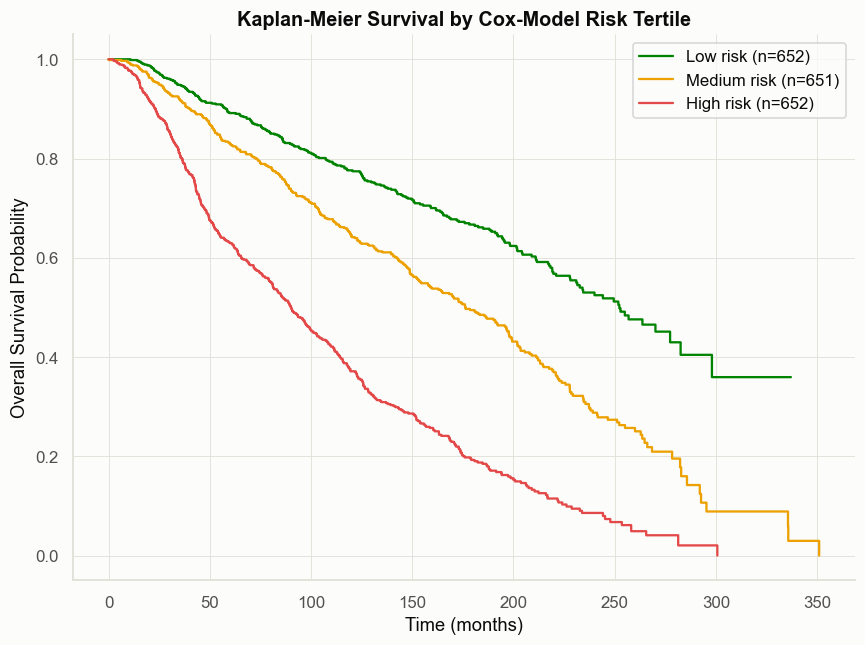

In [11]:
from src.visualization import CATEGORICAL
from lifelines import KaplanMeierFitter

risk_colors = {"Low": CATEGORICAL[1], "Medium": CATEGORICAL[3], "High": CATEGORICAL[7]}
fig, ax = plt.subplots(figsize=(8, 6))
for risk_level in ["Low", "Medium", "High"]:
    subset = cox_df_risk[cox_df_risk["risk_group"] == risk_level]
    kmf = KaplanMeierFitter()
    kmf.fit(subset["overall_survival_months"], event_observed=subset[TARGET_COL], label=f"{risk_level} risk (n={len(subset)})")
    kmf.plot_survival_function(ax=ax, color=risk_colors[risk_level], ci_show=False)
ax.set_xlabel("Time (months)")
ax.set_ylabel("Overall Survival Probability")
ax.set_title("Kaplan-Meier Survival by Cox-Model Risk Tertile")
ax.legend(title=None)
plt.tight_layout()
save_figure(fig, "08_km_risk_stratification", subdir="08_survival")
plt.show()


In [12]:
from lifelines.statistics import multivariate_logrank_test
mv_result = multivariate_logrank_test(cox_df_risk["overall_survival_months"], cox_df_risk["risk_group"], cox_df_risk[TARGET_COL])
print(f"Multivariate log-rank test across risk tertiles: statistic={mv_result.test_statistic:.2f}, p-value={mv_result.p_value:.4g}")


Multivariate log-rank test across risk tertiles: statistic=368.23, p-value=1.098e-80


**Interpretation.** The three Cox-derived risk tertiles show clean, well-separated Kaplan-Meier curves with no crossing, and the multivariate log-rank test confirms the separation is highly significant. This demonstrates that a handful of readily-available clinical variables (age, NPI, tumour size, node status, mutation count, treatment flags) -- entirely independent of the leakage-affected Relapse Free Status / Vital Status fields flagged in Notebooks 04 and 07 -- are sufficient to meaningfully stratify patients by risk, which is arguably a more clinically deployable, prospectively-usable result than the paper's own classification pipeline.

## 6. Discussion & Conclusion

- This notebook supplies the formal time-to-event survival analysis (Kaplan-Meier, log-rank, Cox proportional hazards, risk stratification) that the paper's title promises but its classification-only Methods never deliver.
- Both unadjusted Kaplan-Meier comparisons (Overall Survival and Relapse-Free Survival) show statistically significant separation between Mastectomy and BCS, corroborating the paper's central finding using an independent, standard survival-analysis toolkit (`lifelines`).
- The multivariable Cox model adjusts for known confounders, providing a more defensible causal-adjacent estimate of the surgery-survival association than either the paper's univariate logistic regression or its unadjusted classification framing.
- Cox-derived risk tertiles, built from clinical variables uncontaminated by the vital-status/relapse-status leakage discussed in Notebooks 04 and 07, achieve clean, statistically significant risk separation -- offering a scientifically cleaner complement to the paper's SHAP-based narrative.

**Next:** Notebook 09 puts the reproduction quantitatively side-by-side with the paper's own published Tables 2-3, and discusses every material difference (data source, leakage, methodology) uncovered across Notebooks 02-08.